# Run a simulation, read it, and perform the analysis methods

This notebook:

1. Runs `simulations/simulations_Nspecies_Dynamical_extra_species.py` with `config_Nspecies_Dynamical.yaml`.
2. Reads the resulting abundance time series.
3. Uses the equivalent scripts in `R/` and `analyses/` to perform the inference method and analyze the results.

Run it from the repository root (or from `notebooks/`; the first code cell locates the root automatically).

In [86]:
import matplotlib.pyplot as plt
import numpy as np
import yaml
import subprocess
from pathlib import Path
import os
from tqdm.notebook import tqdm
import ruptures as rpt

In [17]:
# R configuration to be executed in this notebook
r_home = r"C:/Program Files/R/R-4.5.3"
os.environ["R_HOME"] = r_home
os.environ["PATH"] = str(Path(r_home) / "bin" / "x64") + os.pathsep + os.environ.get("PATH", "")
from rpy2 import robjects as ro #To execute R code
from rpy2.robjects import numpy2ri, pandas2ri
from rpy2.robjects import default_converter, numpy2ri, pandas2ri
from rpy2.robjects.conversion import localconverter

In [3]:
plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "cmr10", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False,
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

## 1. Run the gLV simulation

This is the same command documented in the README, invoked from the repository root.

In [ ]:
ROOT = Path.cwd().resolve()
if not (ROOT / "simulations").is_dir():
    ROOT = ROOT.parent

os.chdir(ROOT / "simulations")
%run simulations_Nspecies_Dynamical_extra_species.py config_Nspecies_Dynamical.yaml

{'path': 'output_simulations', 'dt': 0.02, 'Nspecies': 50, 'Nextra': 20, 'x0': 'np.full(Nspecies, 1./Nspecies)', 'r': 1.0, 'mu': -2.0, 'sigma2_int': 0.01, 'sigma2_env': 0.2, 'Nreal': 1, 'Nprint': 1, 'Nsteps': 1000, 'mu_extra': 0.001, 'sigma2_extra': 0.0001}


## 2. Plot the simulated trajectory

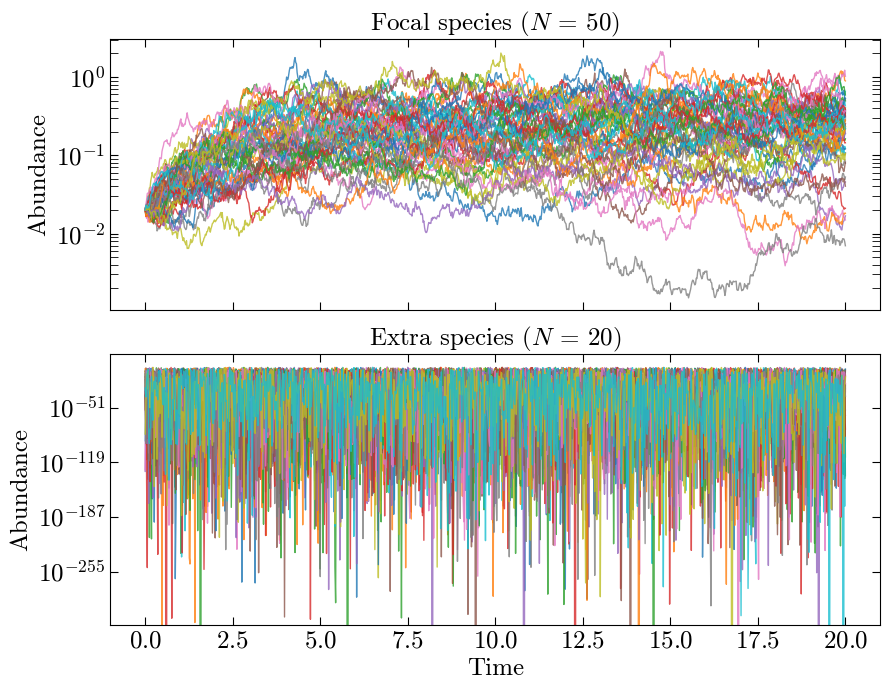

In [21]:
%matplotlib inline

fname = "output_simulations/Sim_0_Temp_0.20_mu_-2.00_sigma_0.10_N_50_extra_20.txt.gz" #change the name of the output if applies
path = Path(fname)
if not path.is_file():
    path = Path.cwd() / "simulations" / fname
Nspecies = 50
Nextra = 20
data = np.loadtxt(path)
time = data[:, 0]
x_focal = data[:, 1 : 1 + Nspecies]
x_extra = data[:, 1 + Nspecies : 1 + Nspecies + Nextra]
print(f"Loaded {path}")
print(f"shape = {data.shape}")
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].semilogy(time, x_focal, lw=1.0, alpha=0.8)
axes[0].set_ylabel("Abundance")
axes[0].set_title(f"Focal species ($N$ = {Nspecies})")
axes[1].semilogy(time, x_extra, lw=1.0, alpha=0.8)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Abundance")
axes[1].set_title(f"Extra species ($N$ = {Nextra})")
for ax in axes:
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        labelsize=18,
        top=True,
        right=True,
        length=6,
    )
fig.tight_layout()
plt.show()

Transient dropped: first 500 of 1001 samples (t < 10.000)
Stationary window: t ∈ [10.000, 20.000]


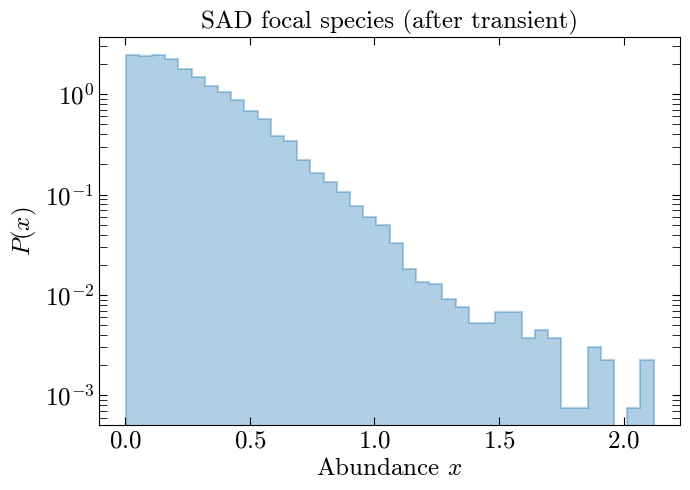

In [27]:
%matplotlib inline

fname = "output_simulations/Sim_0_Temp_0.20_mu_-2.00_sigma_0.10_N_50_extra_20.txt.gz"
path = Path(fname)
if not path.is_file():
    path = Path.cwd() / "simulations" / fname

Nspecies = 50
transient_frac = 0.5  # fraction of the series discarded as transient
data = np.loadtxt(path)
time = data[:, 0]
x_focal = data[:, 1 : 1 + Nspecies]
n_cut = int(np.floor(transient_frac * len(time)))
time_ss = time[n_cut:]
x_ss = x_focal[n_cut:]
x_ss = x_ss[np.isfinite(x_ss) & (x_ss > 0)]
print(f"Transient dropped: first {n_cut} of {len(time)} samples (t < {time[n_cut]:.3f})")
print(f"Stationary window: t ∈ [{time_ss[0]:.3f}, {time_ss[-1]:.3f}]")
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(
    x_ss,
    bins=40,
    density=True,
    histtype="stepfilled",
    alpha=0.35,
    color="C0",
    edgecolor="C0",
    linewidth=1.5,
)
ax.set_xlabel(r"Abundance $x$")
ax.set_ylabel(r"$P(x)$")
ax.set_title(r"SAD focal species (after transient)")
ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    labelsize=18,
    top=True,
    right=True,
    length=6,
)
ax.set_yscale('log')
fig.tight_layout()
plt.show()

## 3. Infer the parameters

In [ ]:
ROOT = Path.cwd().resolve()
if not (ROOT / "R").is_dir():
    ROOT = ROOT.parent
os.chdir(ROOT)

ro.r('source("R/packages.R")')
ro.r('source("R/gLV_moments.R")')
fname0 = "Sim_0_Temp_0.20_mu_-2.00_sigma_0.10_N_50_extra_20"
fname = fname0+".txt.gz"
print(fname)
path = Path(fname)
if not path.is_file():
    path = Path.cwd() / "simulations/output_simulations" / fname


raw = np.loadtxt(path)
X = np.asarray(raw[:, 1:], dtype=float)   # drop time column
Nspecies = X.shape[1]
X = X[:, np.argsort(X.sum(axis=0))[::-1]]  # highest mean abundance first

least = float(np.min(X[X > 0]))
off = least / 10.0
min_S, max_S, boot_B = 3, Nspecies, 1000


cv = default_converter + numpy2ri.converter + pandas2ri.converter
ctx = cv.context() if hasattr(cv, "context") else localconverter(cv)
frames = []
for S in tqdm(range(min_S, max_S + 1), desc="gLV_moments"):
    with ctx:
        ro.globalenv["data"] = X
        ro.globalenv["off"] = float(off)
        ro.globalenv["min_S"] = int(min_S)
        ro.globalenv["max_S"] = int(max_S)
        ro.globalenv["boot_B"] = int(boot_B)
        ro.globalenv["S"] = int(S)
        ro.r("set.seed(123)")
        ro.r("moments_S <- gLV_moments(data = data, ranks = S, off = off, boot_B = boot_B)")
        frames.append(ro.conversion.rpy2py(ro.r("moments_S")))
moments = pd.concat(frames, ignore_index=True)
moments.head(10)

Sim_0_Temp_0.20_mu_-2.00_sigma_0.10_N_50_extra_20.txt.gz


gLV_moments:   0%|          | 0/68 [00:00<?, ?it/s]

[1] 3
[1] 4
[1] 5
[1] 6
[1] 7
[1] 8


In [20]:
fname_out = "moments_"+fname0+"_simulation.csv"
moments.to_csv(ROOT / "output" / fname_out, index=False) #Save the inferred parameters in a .csv

,sigma_env2/r,mu,sigma_int2,r,beta1,e_sigma_env2/r,e_mu,e_sigma_int2,e_r,e_beta1,MWSS
1,0.206838,-0.437197,0.127014,0.982430,-0.018428,0.020235,0.509696,0.050451,0.183200,0.006739,0.988612
2,0.168539,-1.030554,0.116194,1.205196,-0.018366,0.014852,0.504702,0.060558,0.182806,0.005808,1.009985
3,0.161620,-0.993531,0.114901,1.135599,-0.020644,0.012823,0.441395,0.052326,0.162340,0.005118,0.999004
4,0.169664,-0.733495,0.056341,0.982873,-0.023164,0.011477,0.388632,0.036517,0.137752,0.004940,1.002529
5,0.173625,-0.560267,0.031825,0.864704,-0.026005,0.010382,0.317679,0.025905,0.110280,0.004936,0.999364
6,0.173709,-0.508208,0.036370,0.825900,-0.026998,0.010635,0.284795,0.025380,0.100370,0.004453,1.002804
7,0.168818,-0.587955,0.023354,0.834961,-0.027812,0.008298,0.293996,0.022565,0.094593,0.004628,1.005271
8,0.169247,-0.501876,0.014435,0.782021,-0.029826,0.007660,0.259100,0.016720,0.088439,0.004416,0.999572
9,0.172270,-0.421458,0.007999,0.740713,-0.030994,0.006518,0.239056,0.012384,0.077277,0.004231,1.001635
10,0.166452,-0.607189,0.012487,0.812046,-0.029356,0.006370,0.257906,0.016344,0.083887,0.003923,0.999154


## 4. Determination of the core

In [82]:
MWSS = moments["MWSS"].to_numpy()
model = rpt.Pelt(model="l1", jump=1).fit(MWSS)
pen=3.47e-3 #Adjust the penalty to get more than 3 points
change_points = model.predict(pen=pen)
print(np.array(change_points)+min_S)

[16 42 51 53 71]


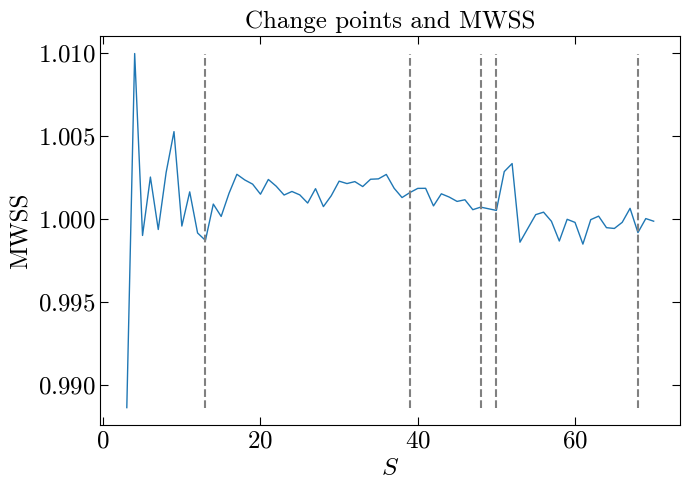

In [83]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(np.arange(min_S,len(MWSS)+min_S,1), MWSS, lw=1.0)
for p in change_points:
    ax.vlines(p,np.min(MWSS),np.max(MWSS),color='gray',linestyle='dashed')
ax.set_xlabel(r"$S$")
ax.set_ylabel(r"MWSS")
ax.set_title(r"Change points and MWSS")
ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    labelsize=18,
    top=True,
    right=True,
    length=6,
)

fig.tight_layout()
plt.show()

We can determine that the core is between 16 and 53 species. We know from the simulation that it is formed exactly by 50.
Let us check if the inferred parameters within the core is in agreement with the true values.

(-2.0, 10.0)

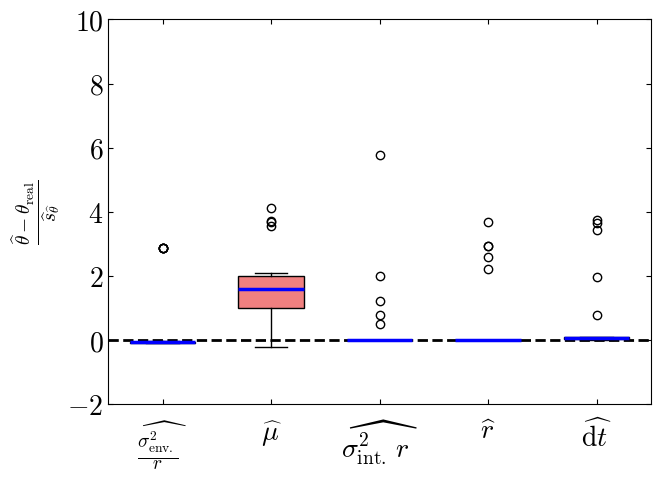

In [101]:
config_path = ROOT / "simulations" / "config_Nspecies_Dynamical.yaml"
with config_path.open() as f:
    config = yaml.safe_load(f)
dt = float(config.get("dt", 0.02))
r = float(config.get("r", 1.0))
mu = float(config.get("mu", 0.0))
sigma_int2 = float(config.get("sigma2_int", 0.01))
sigma_env2 = float(config.get("sigma2_env", 0.1))
core_min = 16
core_max = 53

dt_inf = -moments["beta1"][core_min:core_max].to_numpy()
r_inf = moments["r"][core_min:core_max].to_numpy()
mu_inf = moments["mu"][core_min:core_max].to_numpy()
sigma_int2_inf = moments["sigma_int2"][core_min:core_max].to_numpy()
sigma_env2_r_inf = moments["sigma_env2/r"][core_min:core_max].to_numpy()



dt_core = -moments["beta1"].iloc[48]
r_core = moments["r"].iloc[48]
mu_core = moments["mu"].iloc[48]
sigma_int2_core = moments["sigma_int2"].iloc[48]
sigma_env2_r_core = moments["sigma_env2/r"].iloc[48]

e_dt_core = moments["e_beta1"].iloc[48]
e_r_core = moments["e_r"].iloc[48]
e_mu_core = moments["e_mu"].iloc[48]
e_sigma_int2_core = moments["e_sigma_int2"].iloc[48]
e_sigma_env2_r_core = moments["e_sigma_env2/r"].iloc[48]

z_dt = (dt_inf-dt)/np.std(dt_inf)
z_r = (r_inf-r)/np.std(r_inf)
z_mu = (mu_inf-mu)/np.std(mu_inf)
z_sigma_int2 = (sigma_int2_inf-sigma_int2*r)/np.std(sigma_int2_inf)
z_sigma_env2 = (sigma_env2_r_inf - sigma_env2/r )/np.std(sigma_env2_r_inf)

fig, ax = plt.subplots(figsize=(7, 5))

data = [
    z_sigma_env2, 
    z_mu, 
    z_sigma_int2 , 
    z_r,
    z_dt
]

box = ax.boxplot(
    data,
    patch_artist=True,   # allows filling color
    widths=0.6,
    medianprops=dict(color='blue', linewidth=2.5),
)
ax.axhline(0, color='black', linestyle='--', linewidth=2)

colors = ["lightgrey", "lightcoral", "lightblue", "lightgreen","lightyellow"]
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# --- NEW: Add Error Bars for Index 48 ---
x_pos = [1, 2, 3, 4,5]  # X-coordinates of the boxplots

# Labels
ax.set_xticklabels([r"$\widehat{\frac{\sigma_{\mathrm{env.}}^2}{r}}$", r"$\widehat{\mu}$", r"$\widehat{\sigma_{\mathrm{int.}}^2\,r}$", r"$\widehat{r}$", r"$\widehat{\mathrm{d}t}$"], fontsize=20)
ax.set_ylabel(r"$\frac{\widehat{\theta}-\theta_{\mathrm{real}}}{\widehat{s}_{\widehat{\theta}}}$", fontsize=20)

# Ticks inward and larger size
ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
ax.tick_params(axis='x', which='both', direction='in', labelsize=20, pad=10)

plt.ylim(-2,10)
